### Brain Tumor Classification with `LeNet` and `MLP`

This notebook focuses on training **lightweight deep learning models**-`LeNet` and a **Multilayer Perceptron (MLP)**-for **brain tumor classification** using MRI images. The objective is to evaluate efficient architectures that provide reliable performance while requiring **minimal computational resources**, making them suitable for systems with limited hardware.

The models are trained and evaluated using a publicly available dataset from Kaggle:

> **Brain Tumor MRI Dataset**  
> https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset/data

The workflow covered in this notebook includes:
- Data loading and preprocessing  
- Model architecture design (`LeNet` and `MLP`)  
- Training and validation  
- Performance evaluation and comparison  

This project highlights the effectiveness of lightweight models for medical image classification tasks.


In [97]:
!pip install ptflops -q


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In the following code cell we are going to import all the packages that we are going to use for the rest of this notebook.

In [98]:
import torch
import random
import os
import time
import torchvision
import copy
import json
from pigmenta import PALETTES
from uuid import uuid4
import shutil

import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from IPython.display import FileLink
from shutil import copyfile
from torch.nn import functional as F
from PIL import Image
from torchvision import datasets, transforms
from torch.utils import data
from PIL import Image
from sklearn.metrics import classification_report
from helperfns.tables import tabulate_data
from helperfns.visualization import plot_complicated_confusion_matrix, plot_simple_confusion_matrix
from helperfns.utils import hms_string

from helperfns import visualization
from torchvision import models
from ptflops import get_model_complexity_info
import matplotlib as mpl
import warnings

warnings.filterwarnings("ignore")
print("torch: ", torch.__version__)
print("numpy: ", np.__version__)
print("pandas: ", pd.__version__)

torch:  2.9.0+cu126
numpy:  2.3.3
pandas:  2.3.3


### Seed

In the following code cell we are going to define the `SEED` for all random operation for reproducivity of results in this notebook.

In [2]:
SEED = 23

random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True

### Device

In the following code cell we are going to create a variable `device` that will hold the value of the device that is available so that we can have access to the `GPU` if available.

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### Dataset

The dataset used in this project is sourced from Kaggle and contains labeled MRI images for brain tumor classification:

> **Brain Tumor MRI Dataset**  
> https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset

To ensure reproducibility and efficient data access, the dataset will be downloaded programmatically using the **Kaggle API**. This approach allows seamless integration into the workflow and simplifies data management within the notebook environment.


In [4]:
with open("C:\\Users\\crisp\\Downloads\\kaggle.json", 'r') as reader:
  keys = json.loads(reader.read())
  os.environ['KAGGLE_USERNAME'] = keys['username']
  os.environ['KAGGLE_KEY'] = keys['key']

!kaggle datasets download masoudnickparvar/brain-tumor-mri-dataset --unzip -q

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)


In the next code cell, we will **count the number of samples in each class** for both the **training** and **testing** datasets. This step helps us understand the **class distribution** and identify any potential imbalance that might affect model training.


In [5]:
train_samples = dict(
    zip(os.listdir('Training'), [len(os.listdir(os.path.join('Training', i))) for i in os.listdir('Training')])
)
test_samples =  dict(
    zip(os.listdir('Testing'), [len(os.listdir(os.path.join('Testing', i))) for i in os.listdir('Testing')])
)

test_samples, train_samples

({'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400},
 {'glioma': 1400, 'meningioma': 1400, 'notumor': 1400, 'pituitary': 1400})

In the following code cell, we will **visualize the class distribution** of the dataset using a **pie chart**. This graphical representation provides a clear view of the proportion of samples in each class, helping to identify any imbalance in the dataset.


<Figure size 300x300 with 0 Axes>

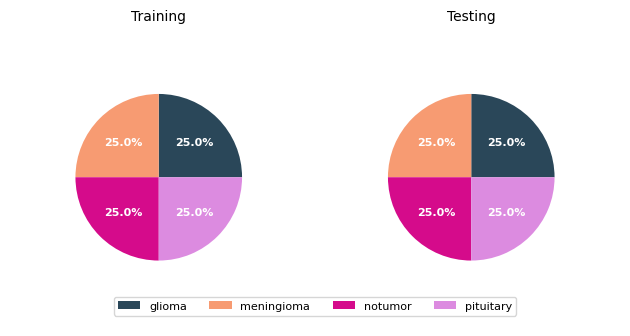

In [24]:
plt.figure(figsize=(3, 3))

def fmt(x, total):
    return '{:.1f}%\n({:.0f})'.format(x, total*x/100)

fig, axes = plt.subplots(1, 2)
wedges1, _, _ = axes[0].pie(
    train_samples.values(),
    labels=None, 
    autopct='%1.1f%%',
    textprops={'color': 'white', 'fontsize': 8, 'weight': 'bold'},
    colors=PALETTES.retro[10:],
    radius=.7
)
axes[0].set_title("Training", fontsize=10)

wedges2, _, _ = axes[1].pie(
    test_samples.values(),
    labels=None,
    autopct='%1.1f%%',
    textprops={'color': 'white', 'fontsize': 8, 'weight': 'bold'},
    colors=PALETTES.retro[10:],
    radius=.7
)
axes[1].set_title("Testing", fontsize=10)

fig.legend(
    wedges1,
    train_samples.keys(),
    loc="lower center",
    bbox_to_anchor=(0.5, .2),
    ncol=4,
    fontsize=8
)
plt.tight_layout()
plt.show()

### Channel Means and Standard Deviations

In the next code cell, we will **compute the mean and standard deviation for each color channel** across all images in the dataset. These values are essential for **normalizing the images** during preprocessing, which helps the models train more effectively and converge faster.

In [25]:
train_data = datasets.ImageFolder(
    root='Training',
    transform= transforms.Compose([
        transforms.Resize((96, 96)),
        transforms.ToTensor()
      ])
    )
means = torch.zeros(3)
stds = torch.zeros(3)

for img, label in train_data:
  means += torch.mean(img, dim = (1,2))
  stds += torch.std(img, dim = (1,2))

means /= len(train_data)
stds /= len(train_data)

print(f'Calculated means: {means}')
print(f'Calculated stds: {stds}')


Calculated means: tensor([0.1840, 0.1840, 0.1840])
Calculated stds: tensor([0.1714, 0.1714, 0.1715])


From the computed channel means and standard deviations, we will **average them to obtain a single value**. This value will be used to **normalize all images**. Additionally, the images will be **resized to 96×96 pixels** and **converted to grayscale**. For the training set, we will also apply **data augmentation** to improve model generalization.  

The transformations for each dataset split are as follows:

```python
"train": transforms.Compose([
    transforms.Resize([96, 96]),
    transforms.RandomRotation(5),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomCrop(96, padding=2),
    transforms.ToTensor(),
    transforms.Grayscale(num_output_channels=1),
    transforms.Normalize(mean=[mean], std=[std], inplace=False)
]),
"valid": transforms.Compose([
    transforms.Resize([96, 96]),
    transforms.ToTensor(),
    transforms.Grayscale(num_output_channels=1),
    transforms.Normalize(mean=[mean], std=[std], inplace=False)
]),
"test": transforms.Compose([
    transforms.Resize([96, 96]),
    transforms.ToTensor(),
    transforms.Grayscale(num_output_channels=1),
    transforms.Normalize(mean=[mean], std=[std], inplace=False)
])
```


These transformations ensure that the data is standardized, and the training set benefits from random augmentations to make the model more robust.

In [26]:
mean = means.mean().item()
std = stds.mean().item()

image_transforms = {
    "train": transforms.Compose([
       transforms.Resize([96,96]),
       transforms.RandomRotation(5),
       transforms.RandomHorizontalFlip(.5),
       transforms.RandomCrop(96, padding=2),
       transforms.ToTensor(),
       transforms.Grayscale(
         num_output_channels =1
       ),
       transforms.Normalize(mean=[mean], std=[std], inplace=False)                         
    ]),
    "valid": transforms.Compose([
        transforms.Resize([96,96]),
        transforms.ToTensor(),
        transforms.Grayscale(
         num_output_channels=1
       ),
        transforms.Normalize(mean=[mean], std=[std], inplace=False)
    ]),
    "test": transforms.Compose([
        transforms.Resize([96,96]),
        transforms.ToTensor(),
        transforms.Grayscale(
         num_output_channels =1
       ),
        transforms.Normalize(mean=[mean], std=[std], inplace=False)
    ])
}

In the following code cell, we will create datasets using the `ImageFolder` class from PyTorch. This class **automatically maps each class to its corresponding images** and handles much of the underlying data management, making it easy to prepare both the **training** and **testing** sets for model training and evaluation.


In [27]:
train_dataset = datasets.ImageFolder('Training', transform = image_transforms['train'])
test_dataset = datasets.ImageFolder('Testing', transform = image_transforms['test'])
class_names = train_dataset.classes
class_names

['glioma', 'meningioma', 'notumor', 'pituitary']

We can check the class to index mapping of the dataset as follows..

In [28]:
train_dataset.class_to_idx

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

### Validation Split

Next, we will **reserve 20% of the training data** to create a **validation set**. This split allows us to **monitor the model's performance** on unseen data during training and helps prevent overfitting.

In [29]:
VALID_RATIO = 0.2
# Split the training data into train + validation
n_valid_examples = int(len(train_dataset) * VALID_RATIO)
n_train_examples = len(train_dataset) - n_valid_examples
train_data, valid_data = data.random_split(train_dataset,
                                           [n_train_examples, n_valid_examples])


> **Note:** After reserving the validation set from the training data, the resulting subsets still inherit the **training transforms** by default. To apply the correct transformations for each split, we will **create copies of the subsets** and **override their transforms** with the appropriate transformations for  **validation** datasets


In [30]:
valid_dataset = copy.deepcopy(valid_data)
valid_dataset.dataset.transform = image_transforms['valid']

In the following code cell we are going to use the pie chat to visualize the examples that we have in each subset.

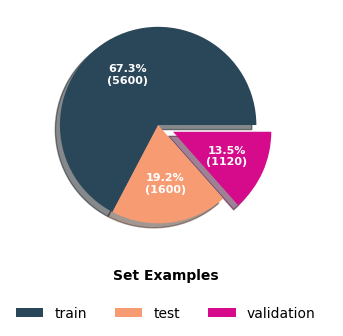

In [31]:
plt.figure(figsize=(3, 3))

plt.pie(
    [len(train_dataset), len(test_dataset), len(valid_dataset)], explode= [.0, .0, .1],
    labels=['train', 'test', 'validation'],
    pctdistance=0.6, shadow=True, autopct=lambda x: fmt(x, sum([len(train_dataset), len(test_dataset), len(valid_dataset)])),
    textprops={'color': 'white', 'fontsize': 8, 'weight': 'bold'},
    radius=.6, colors=PALETTES.retro[10:]
)
plt.xlabel('Set Examples', weight="bold", fontsize=10, labelpad=20)
plt.legend(loc="lower center",
    ncol=3, frameon=False, fontsize=10, title="",
    bbox_to_anchor=(0.5, -.4),
)
plt.axis('equal')
plt.show()

In the following code cell we are going to plot a `barplot` for the label distribution.

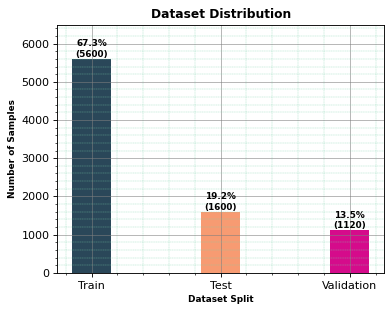

In [95]:
labels = ['Train', 'Test', 'Validation']
values = [len(train_dataset), len(test_dataset), len(valid_dataset)]

def fmt_bar(x, total):
    return '{:.1f}%\n({:.0f})'.format(x/total *100, x)
    
plt.figure(figsize=(5, 4), dpi=80 )
plt.ylim(0, max(values) * 1.16)
bars = plt.bar(labels, values, width=.3, color=PALETTES.retro[10:])
for index, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        fmt_bar(values[index], sum(values)),
        ha='center',
        va='bottom',
        fontsize=8,
        weight='bold'
    )

plt.xlabel('Dataset Split', fontsize=8, weight='bold')
plt.ylabel('Number of Samples', fontsize=8, weight='bold')
plt.title('Dataset Distribution', fontsize=11, weight='bold')
plt.minorticks_on()
plt.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
plt.grid(which='minor', color='#7ED4AD', linestyle='--', linewidth=0.3)
plt.tight_layout()
plt.show()

Next we are going to create iterators and we are going to set the batch size to be `128`.

In [32]:
BATCH_SIZE = 128
train_iterator = data.DataLoader(
    train_dataset, shuffle=True, batch_size= BATCH_SIZE
)
valid_iterator = data.DataLoader(
    valid_dataset, batch_size= BATCH_SIZE
)
test_iterator = data.DataLoader(
    test_dataset,  batch_size= BATCH_SIZE
)

### Visualizing Images

In this section of the notebook we are going to visualize the images that we have in our dataset with their respective labels.

In [33]:
def normalize_image(image):
  image_min = image.min()
  image_max = image.max()
  image.clamp_(min = image_min, max = image_max)
  image.add_(-image_min).div_(image_max - image_min + 1e-5)
  return image

Next we are going to define the `plot_images` function which is responsible for plotting images.

In [34]:
def plot_images(images, labels, normalize = True):
  n_images = len(images)
  rows = int(np.sqrt(n_images))
  cols = int(np.sqrt(n_images))
  fig = plt.figure(figsize = (10, 10))
  for i in range(rows*cols):
    ax = fig.add_subplot(rows, cols, i+1)
    image = images[i]
    if normalize:
        image = normalize_image(image)

    ax.imshow(image.permute(1, 2, 0).cpu().numpy(), cmap='gray')
    ax.set_title(class_names[labels[i]], fontsize=10, color='g' if labels[i] == 2 else 'r')
    ax.axis('off')


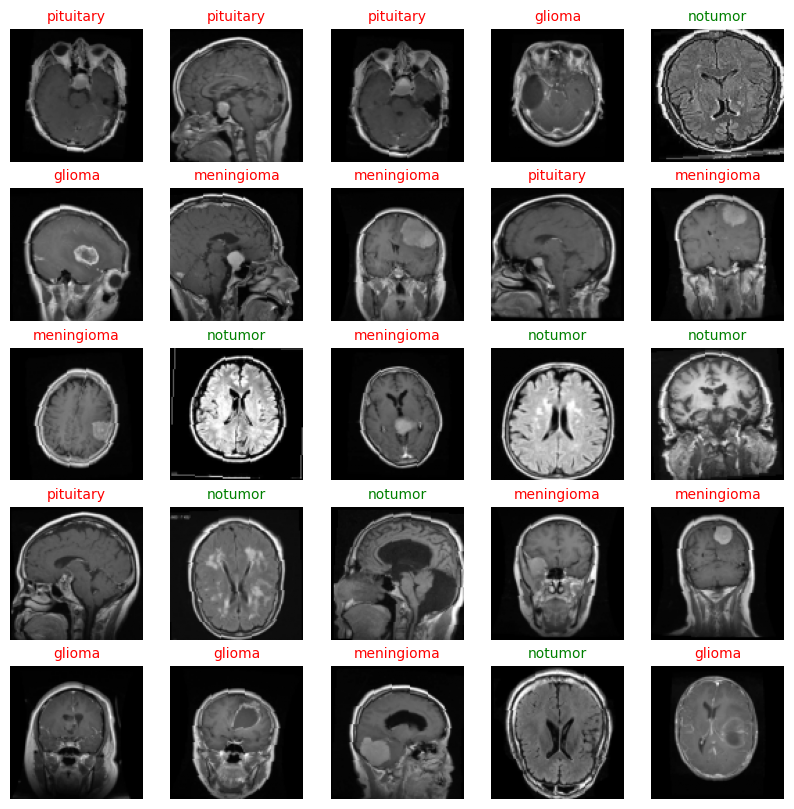

In [35]:
N_IMAGES = 25
labeled_data = next(iter(train_iterator))

images, labels = labeled_data[0][:N_IMAGES], labeled_data[1][:N_IMAGES]
plot_images(images, labels)

### MLP Model

In the next code cell, we will **define a Multilayer Perceptron (MLP) model**. This fully connected neural network will serve as a **lightweight baseline** for brain tumor classification and will process the flattened image data to predict the corresponding class labels.


In [36]:
class MLP(nn.Module):
  def __init__(self, input_dim, output_dim, dropout=.5):
    super(MLP, self).__init__()
    self.classifier = nn.Sequential(
        nn.Linear(input_dim, 250),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(250, 100),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(100, output_dim)
    )

  def forward(self, x):
    batch_size = x.shape[0]
    x = x.view(batch_size, -1)
    x = self.classifier(x)
    return x

### LeNet

In the following code cell, we will **define a LeNet model**. Unlike a standard MLP, LeNet is a **convolutional neural network (CNN)** that extracts spatial features from images, making it well-suited for image classification tasks like brain tumor detection. This model serves as a **lightweight yet effective baseline** for comparing performance against the MLP.


In [37]:
class LeNet(nn.Module):
    def __init__(self, output_dim, input_size=96):
        super(LeNet, self).__init__()
        self.convs = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2),                 
            nn.Conv2d(6, 16, kernel_size=5),  
            nn.ReLU(),
            nn.MaxPool2d(2)                 
        )
        
        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_size, input_size)
            dummy = self.convs(dummy)
            self.flatten_dim = dummy.view(1, -1).shape[1]
        self.classifier = nn.Sequential(
            nn.Linear(self.flatten_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        x = self.convs(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In the following code cell, we will **create an instance of the `MLP` model**. This step initializes the model with the defined architecture, making it ready for training on the brain tumor dataset.


In [38]:
OUTPUT_DIM = 1 if len(class_names) == 2 else len(class_names)

INPUT_DIM = 96 * 96
OUTPUT_DIM = 1 if len(class_names) == 2 else len(class_names)
dropout = .5
mlp = MLP(INPUT_DIM, OUTPUT_DIM, dropout).to(device)
mlp

MLP(
  (classifier): Sequential(
    (0): Linear(in_features=9216, out_features=250, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=250, out_features=100, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=100, out_features=4, bias=True)
  )
)

In the following code cell, we will **create an instance of the `LeNet` model**. This initializes the convolutional network with the defined architecture, preparing it for training and evaluation on the brain tumor dataset.


In [39]:
lenet = LeNet(OUTPUT_DIM).to(device)
lenet

LeNet(
  (convs): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=7056, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=4, bias=True)
  )
)

Next we are going to create a function that will count the model parameters.

In [40]:
def count_params(model):
  total_params = sum([p.numel() for p in model.parameters()])
  trainable_params = sum([p.numel() for p in model.parameters() if p.requires_grad])
  return f'{total_params:,}', f'{trainable_params:,}', f'{total_params - trainable_params:,}'

Then we will visualize the model parameters using a table.

In [41]:
tabulate_data(
    ["NAME", "TOTAL PARAMETERS", "TRAINABLE PARAMETERS", "NON-TRAINABLE PARAMETERS"],
    [
      ['MLP', *count_params(mlp)],
      ['LeNet', *count_params(lenet)], 
    ],
    "MODELS' PARAMETERS"
)


MODELS' PARAMETERS
+-------+------------------+----------------------+--------------------------+
| NAME  | TOTAL PARAMETERS | TRAINABLE PARAMETERS | NON-TRAINABLE PARAMETERS |
+-------+------------------+----------------------+--------------------------+
| MLP   |        2,329,754 |            2,329,754 |                        0 |
| LeNet |          914,384 |              914,384 |                        0 |
+-------+------------------+----------------------+--------------------------+


### Criterion and Optimizer

Next, we will define the **optimizer** and **loss function** for training our models. We will use the **Adam optimizer** with default parameters for efficient gradient-based optimization. For the loss function, we will use **CrossEntropyLoss**, which is suitable for **multi-class classification tasks** like brain tumor detection.


In [44]:
optimizers = {
    'mlp': torch.optim.Adam(mlp.parameters()),
    'lenet': torch.optim.Adam(lenet.parameters()),
}

criterions = {
    'mlp': nn.CrossEntropyLoss().to(device),
    'lenet': nn.CrossEntropyLoss().to(device),
}

In the following code cell, we will define the `categorical_accuracy` function. This function **calculates the accuracy** of the model by comparing the predicted class labels with the true labels, providing a clear metric for evaluating model performance on classification tasks.

In [45]:
def categorical_accuracy(y_pred, y):
  top_pred = y_pred.argmax(1, keepdim=True)
  correct = top_pred.eq(y.view_as(top_pred)).sum()
  acc = correct.float()/ y.shape[0]
  return acc

### Train and Evaluate Functions

In the following code cell we are going to define the `train` and `evaluate` fuctions.

In [46]:
def train(model, iterator, optimizer, criterion, device):
  epoch_loss, epoch_acc = 0, 0
  model.train()
  for (x, y) in iterator:
    # features and labels to the device
    x = x.to(device)
    y = y.to(device).long()
    # Zero the gradients
    optimizer.zero_grad()
    y_pred = model(x)
    # Calculate the loss and accuracy
    y_pred = y_pred.squeeze()

    loss = criterion(y_pred, y)
    acc = categorical_accuracy(y_pred, y)
    # Backward propagate
    loss.backward()
    # Update the weights
    optimizer.step()
    epoch_loss +=loss.item()
    epoch_acc += acc.item()
  return epoch_loss/len(iterator), epoch_acc/len(iterator)

def evaluate(model, iterator, criterion, device):
  epoch_loss, epoch_acc = 0, 0
  model.eval()
  with torch.no_grad():
    for (x, y) in iterator:
      x = x.to(device)
      y = y.to(device).long()
      y_pred = model(x)
      y_pred = y_pred.squeeze()
      loss = criterion(y_pred, y)
      acc = categorical_accuracy(y_pred, y)

      epoch_loss += loss.item()
      epoch_acc += acc.item()
  return epoch_loss/len(iterator), epoch_acc/len(iterator)

Next we are going to create a `History` wrapper class so that we can keep in track of the model's metrics during training.

In [47]:
class History:
  def __init__(self):
    self.train_losses = list()
    self.train_acc = list()
    self.epoch_train_time = list()
    self.val_losses = list()
    self.val_acc = list()

  def add(self, train_loss:float, train_acc:float, val_loss:float, val_acc:float, elt:float):
    self.train_losses.append(train_loss)
    self.val_losses.append(val_loss)
    self.train_acc.append(train_acc)
    self.val_acc.append(val_acc)
    self.epoch_train_time.append(elt)

Next we are going to define the `train_model` function which is responsible for training the model and return model training history.

In [48]:
EPOCHS = 100

def train_model(model, model_name, train_iterator, optimizer, criterion, device, valid_iterator):
  best_valid_loss = float('inf')
  column_names = ["Set", "Loss", "Accuracy", "ETA (time)"]
  last_saved_epoch = 1

  history = History()
  training_start = time.time()
  for epoch in range(EPOCHS):
    start = time.time()

    train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate(model, valid_iterator, criterion, device)

    save_status = "(not saving)"
    if valid_loss < best_valid_loss:
      best_valid_loss = valid_loss
      save_status = "(saving)"
      last_saved_epoch = epoch + 1
      torch.save(model.state_dict(), model_name)

    end = time.time()
    history.add(train_loss, train_acc, valid_loss, valid_acc, end-start)


    data_rows = [
        ["Train", f'{train_loss:.3f}', f'{train_acc * 100:.2f}%', hms_string(end-start)],
        ["Validation", f'{valid_loss:.3f}', f'{valid_acc * 100:.2f}%', ""]
    ]

    title = f"{model_name.replace('.pt', '')}: EPOCH {epoch+1:02}/{EPOCHS}: {save_status}"
    tabulate_data(column_names, data_rows, title)

  training_end = time.time()
  return history, training_end - training_start, last_saved_epoch

Next we are going to run the train loop for the `MLP` model.

In [49]:
mlp_history, mlp_training_end, mlp_last_saved_epoch = train_model(
    mlp, 'mlp.pt', train_iterator, optimizers['mlp'], criterions['mlp'], device, valid_iterator
)

mlp: EPOCH 01/100: (saving)
+------------+-------+----------+------------+
| Set        |  Loss | Accuracy | ETA (time) |
+------------+-------+----------+------------+
| Train      | 1.079 |   56.35% | 0:00:53.79 |
| Validation | 0.757 |   70.69% |            |
+------------+-------+----------+------------+
mlp: EPOCH 02/100: (saving)
+------------+-------+----------+------------+
| Set        |  Loss | Accuracy | ETA (time) |
+------------+-------+----------+------------+
| Train      | 0.852 |   66.60% | 0:00:52.63 |
| Validation | 0.658 |   76.24% |            |
+------------+-------+----------+------------+
mlp: EPOCH 03/100: (saving)
+------------+-------+----------+------------+
| Set        |  Loss | Accuracy | ETA (time) |
+------------+-------+----------+------------+
| Train      | 0.781 |   69.66% | 0:00:52.76 |
| Validation | 0.598 |   78.94% |            |
+------------+-------+----------+------------+
mlp: EPOCH 04/100: (saving)
+------------+-------+----------+---------

In [50]:
lenet_history, lenet_training_end, lenet_last_saved_epoch = train_model(
    lenet, 'lenet.pt', train_iterator, optimizers['lenet'], criterions['mlp'], device, valid_iterator
)

lenet: EPOCH 01/100: (saving)
+------------+-------+----------+------------+
| Set        |  Loss | Accuracy | ETA (time) |
+------------+-------+----------+------------+
| Train      | 0.786 |   68.03% | 0:00:58.86 |
| Validation | 0.554 |   77.86% |            |
+------------+-------+----------+------------+
lenet: EPOCH 02/100: (saving)
+------------+-------+----------+------------+
| Set        |  Loss | Accuracy | ETA (time) |
+------------+-------+----------+------------+
| Train      | 0.545 |   79.24% | 0:00:57.09 |
| Validation | 0.481 |   80.56% |            |
+------------+-------+----------+------------+
lenet: EPOCH 03/100: (saving)
+------------+-------+----------+------------+
| Set        |  Loss | Accuracy | ETA (time) |
+------------+-------+----------+------------+
| Train      | 0.476 |   81.53% | 0:00:57.84 |
| Validation | 0.431 |   83.16% |            |
+------------+-------+----------+------------+
lenet: EPOCH 04/100: (saving)
+------------+-------+----------+-

### Model Training Time

In the following code cell, we will use a **table** to display the **total training time** for the model as well as the **last saved epoch**. This provides a quick summary of training efficiency and progress for each model.


In [51]:
rows = [
    ['mlp', f'{EPOCHS}', f'{hms_string(mlp_training_end)}', f'{mlp_last_saved_epoch}'],
    ['lenet', f'{EPOCHS}', f'{hms_string(lenet_training_end)}', f'{lenet_last_saved_epoch}']
]
tabulate_data(['MODEL','TOTAL EPOCHS', 'TOTAL TRAINING TIME', 'LAST SAVED EPOCH'], rows, "TOTAL TRAINING TIME")

TOTAL TRAINING TIME
+-------+--------------+---------------------+------------------+
| MODEL | TOTAL EPOCHS | TOTAL TRAINING TIME | LAST SAVED EPOCH |
+-------+--------------+---------------------+------------------+
| mlp   |          100 |          1:30:26.79 |              100 |
| lenet |          100 |          1:16:45.26 |               86 |
+-------+--------------+---------------------+------------------+


In the following code cell, we will **visualize the model's training time per epoch**. This allows us to analyze how long each epoch takes and helps identify any potential bottlenecks in the training process.


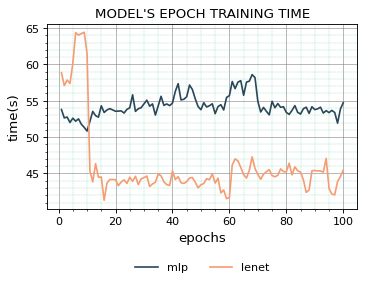

In [52]:
epochs = np.arange(1, EPOCHS + 1)
plt.figure(figsize=(5, 3), dpi=80)
plt.plot(epochs, mlp_history.epoch_train_time, label="mlp", color=PALETTES.retro[10])
plt.plot(epochs, lenet_history.epoch_train_time, label="lenet", color=PALETTES.retro[11])
plt.title("MODEL'S EPOCH TRAINING TIME", color="k", fontsize=12)
plt.xlabel("epochs", fontsize=12)
plt.ylabel("time(s)", fontsize=12)

plt.minorticks_on()
plt.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
plt.grid(which='minor', color='#7ED4AD', linestyle='--', linewidth=0.3)
plt.legend(loc="lower center",
    ncol=3, frameon=False, fontsize=10, title="",
    bbox_to_anchor=(0.5, -.4),
)
plt.show()

### Validation and Training Accuracies

In the following code cell, we will **visualize the model's training and validation accuracies per epoch** using line graphs. This provides insight into how well the model is learning over time and helps monitor **performance improvements** across epochs.


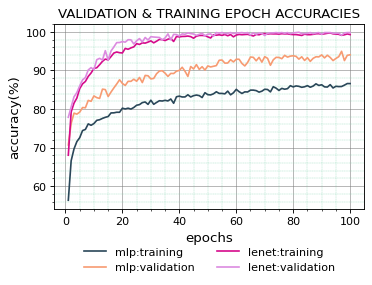

In [53]:
plt.figure(figsize=(5, 3), dpi=80)
plt.plot(epochs, [i * 100 for i in mlp_history.train_acc], label="mlp:training", color=PALETTES.retro[10])
plt.plot(epochs, [i * 100 for i in mlp_history.val_acc], label="mlp:validation", color=PALETTES.retro[11])
plt.plot(epochs, [i * 100 for i in lenet_history.train_acc], label="lenet:training", color=PALETTES.retro[12])
plt.plot(epochs, [i * 100 for i in lenet_history.val_acc], label="lenet:validation", color=PALETTES.retro[13])

plt.title("VALIDATION & TRAINING EPOCH ACCURACIES", color="k", fontsize=12)
plt.xlabel("epochs", fontsize=12)
plt.ylabel("accuracy(%)", fontsize=12)
plt.legend(loc="lower center",
    ncol=2, frameon=False, fontsize=10, title="",
    bbox_to_anchor=(0.5, -.4),
)
plt.minorticks_on()
plt.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
plt.grid(which='minor', color='#7ED4AD', linestyle='--', linewidth=0.3)
plt.show()

### Validation and Training Losses

In the following code cell, we will **visualize the model's training and validation losses per epoch** using line graphs. This helps track the model's learning progress and identify potential issues like **overfitting** or **underfitting**.


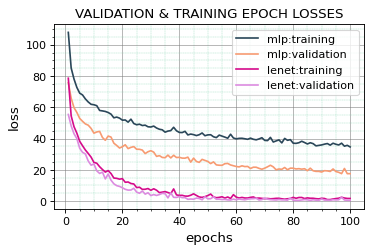

In [54]:
plt.figure(figsize=(5, 3), dpi=80)

plt.plot(epochs, [i * 100 for i in mlp_history.train_losses], label="mlp:training", color=PALETTES.retro[10])
plt.plot(epochs, [i * 100 for i in mlp_history.val_losses], label="mlp:validation", color=PALETTES.retro[11])
plt.plot(epochs, [i * 100 for i in lenet_history.train_losses], label="lenet:training", color=PALETTES.retro[12])
plt.plot(epochs, [i * 100 for i in lenet_history.val_losses], label="lenet:validation", color=PALETTES.retro[13])

plt.title("VALIDATION & TRAINING EPOCH LOSSES", color="k", fontsize=12)
plt.xlabel("epochs", fontsize=12)
plt.ylabel("loss", fontsize=12)
plt.legend()

plt.minorticks_on()
plt.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
plt.grid(which='minor', color='#7ED4AD', linestyle='--', linewidth=0.3)
plt.show()

### Best Model Evaluation

In the following code cell, we will **define a function to evaluate the best saved model** from training. This function will compute both the **loss** and **accuracy** on the **testing dataset**, providing a clear measure of how well the model generalizes to unseen data.


In [55]:
def evaluate_best_model(model, model_name, test_iterator, criterion, device):
  model.load_state_dict(torch.load(model_name, weights_only=True))
  test_loss, test_acc = evaluate(model, test_iterator, criterion, device)
  return f'{test_loss:.2f}', f'{test_acc * 100:.2f}'


tabulate_data(
    ["NAME", "LOSS", "ACCURACY (%)"],
    [
        ['mlp', *evaluate_best_model(mlp, 'mlp.pt', test_iterator, criterions['mlp'], device)],
        ['lenet', *evaluate_best_model(lenet, 'lenet.pt', test_iterator, criterions['lenet'], device)],
    ],
    "BEST MODEL'S LOSS AND ACCURACY"
)

BEST MODEL'S LOSS AND ACCURACY
+-------+------+--------------+
| NAME  | LOSS | ACCURACY (%) |
+-------+------+--------------+
| mlp   | 0.87 |        84.38 |
| lenet | 1.65 |        92.67 |
+-------+------+--------------+


### 🔍 FLOPs in Neural Networks (Model Complexity)

### 📌 What are FLOPs?

**FLOPs (Floating Point Operations)** measure the number of arithmetic operations (multiplications and additions) required for a forward pass in a neural network.

They are used to estimate the **computational complexity** of a model independent of hardware.

---

### 📌 FLOPs vs MACs

- **MAC (Multiply–Accumulate)** = 1 multiplication + 1 addition  
- Therefore:

$$
\text{FLOPs} \approx 2 \times \text{MACs}
$$

---

### 🧠 FLOPs Calculation

### 🔹 Fully Connected Layer (MLP)

$$
\text{FLOPs} = 2 \times (N_{in} \times N_{out})
$$

Where:
- $N_{in}$ = number of input neurons  
- $N_{out}$ = number of output neurons  

---

### 🔹 Convolutional Layer (CNN)

$$
\text{FLOPs} = 2 \times (K^2 \times C_{in} \times H_{out} \times W_{out} \times C_{out})
$$

Where:
- $K$ = kernel size  
- $C_{in}$ = input channels  
- $C_{out}$ = number of filters  
- $H_{out}, W_{out}$ = output feature map size  

---


### 📊 Why FLOPs Matter

FLOPs help to:

- Compare model efficiency  
- Estimate computational cost  
- Evaluate suitability for edge devices  
- Complement parameter count and training time  

---

### ⚠️ Limitations

- Does not account for memory access or hardware optimizations  
- Similar FLOPs ≠ same runtime performance  



In [100]:
def compute_flops(model):
    with torch.cuda.device(0):  
        macs, params = get_model_complexity_info(
            model,
            (1, 96, 96),
            as_strings=True,
            print_per_layer_stat=False,
            verbose=False
        )
    return macs, params

macs, params = compute_flops(lenet)
print(f"LeNet FLOPs (MACs): {macs}")
print(f"LeNet Params: {params}")
macs, params = compute_flops(mlp)
print()
print(f"MLP FLOPs (MACs): {macs}")
print(f"MLP Params: {params}")

LeNet FLOPs (MACs): 6.81 MMac
LeNet Params: 914.38 k

MLP FLOPs (MACs): 2.33 MMac
MLP Params: 2.33 M


### Model Evaluation Metrics

In this section, we will **evaluate the best-performing model** and visualize its performance using key metrics. For this multi-class classification task, we will use:

1. **Confusion Matrix** – to see how well the model predicts each class.  
2. **Classification Report** – to get precision, recall, F1-score, and support for each class.  

The first step is to **obtain predictions** from the training dataset, which will then be used to compute these evaluation metrics.


In [56]:
def get_predictions(model, iterator, device):
  model.eval()
  images = []
  labels = []
  probs = []
  with torch.no_grad():
    for (x, y) in iterator:
      x = x.to(device)
      y_pred = model(x)
      y_prob = F.softmax(y_pred, dim = -1)
      top_pred = y_prob.argmax(1, keepdim = True)
      images.append(x.cpu())
      labels.append(y.cpu())
      probs.append(y_prob.cpu())
  images = torch.cat(images, dim = 0)
  labels = torch.cat(labels, dim = 0)
  probs = torch.cat(probs, dim = 0)
  return images, labels, probs

mlp_test_images, mlp_test_labels, mlp_probs = get_predictions(mlp, test_iterator, device)
lenet_test_images, lenet_test_labels, lenet_probs = get_predictions(lenet, test_iterator, device)

Next we are going to convert our predictions from probabilities to real labels.

In [57]:
mlp_preds = torch.argmax(mlp_probs, 1).numpy().astype(np.int32)
mlp_test_labels = mlp_test_labels.numpy()

lenet_preds = torch.argmax(lenet_probs, 1).numpy().astype(np.int32)
lenet_test_labels = lenet_test_labels.numpy()

### Plotting Predictions

In this section, we will **visualize the model's predictions** on sample images from the dataset. This helps to **qualitatively assess** how well the model is performing and provides an intuitive understanding of its classification behavior.


In [58]:

def get_predictions_labels(test_images, preds, test_labels):
    test_images_labels = list(zip(test_images, preds, test_labels))
    random.shuffle(test_images_labels)
    y_true = []
    y_pred = []
    images = []
    
    for img, pred, label in test_images_labels[:24]:
      y_true.append(label)
      y_pred.append(pred)
      images.append(img)
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return images, y_true, y_pred


mlp_images, mlp_y_true, mlp_y_pred = get_predictions_labels(mlp_test_images, mlp_preds, mlp_test_labels)
lenet_images, lenet_y_true, lenet_y_pred = get_predictions_labels(lenet_test_images, lenet_preds, lenet_test_labels)

Next we are going to define the function that will plot the predictions for us.

In [59]:
def plot_predictions_images(images_and_classes,
                            labels_true, labels_pred,
                            cols=5):
    rows = 3
    fig = plt.figure()
    fig.set_size_inches(cols * 2, rows * 2)
    for i, (image, label_true, label_pred) in enumerate(zip(images_and_classes, labels_true.astype("int32"), labels_pred)):
        plt.subplot(rows, cols, i + 1)
        plt.axis('off')
        image = normalize_image(image)
        plt.imshow(image.permute(1, 2, 0).cpu().numpy(), cmap="gray")
        plt.title(class_names[label_pred], color ='g' if label_true == label_pred else 'r', fontsize=10 )

Next, we will **plot the predictions made by the `MLP` model**. This visualization allows us to **see how accurately the MLP classifies sample images** and to compare its performance against other models like LeNet.


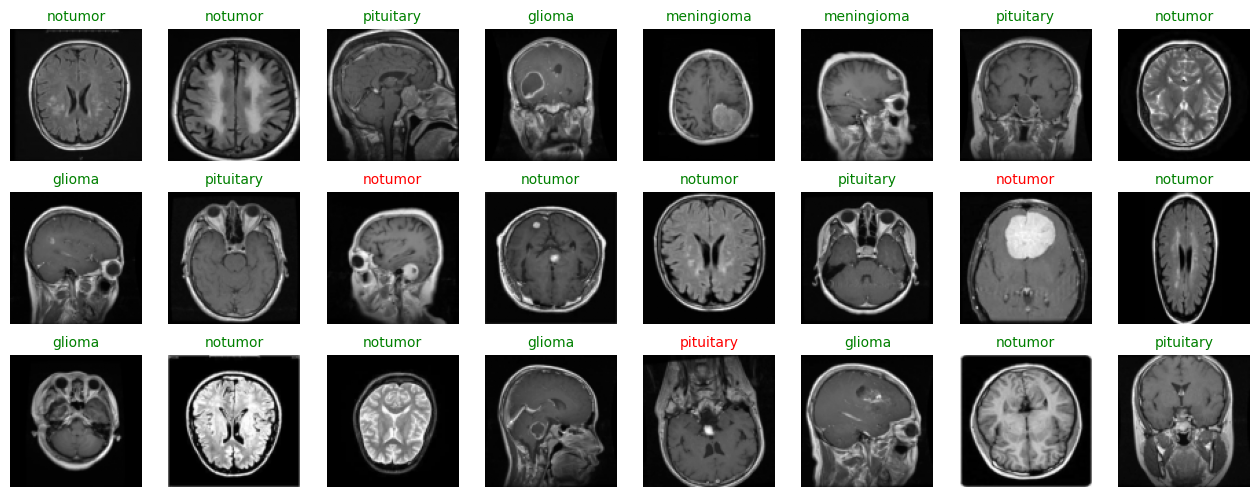

In [60]:
plot_predictions_images(mlp_images[:24], mlp_y_true[:24], mlp_y_pred[:24], cols=8)

Next, we will **plot the predictions made by the `LeNet` model**. This visualization allows us to **see how accurately the LeNeT classifies sample images** and to compare its performance against other models like MLP.


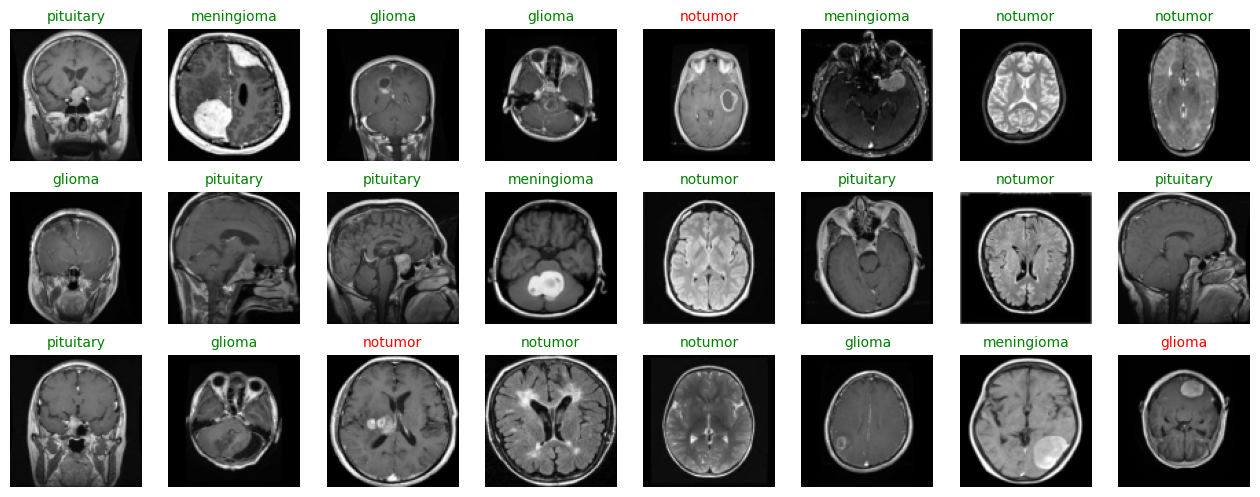

In [61]:
plot_predictions_images(lenet_images[:24], lenet_y_true[:24], lenet_y_pred[:24], cols=8)

### Confusion Matrix

In the following code cell, we will **visualize the confusion matrix** for our model using the **test dataset**. The confusion matrix provides a detailed view of how well the model predicts each class and highlights any misclassifications.

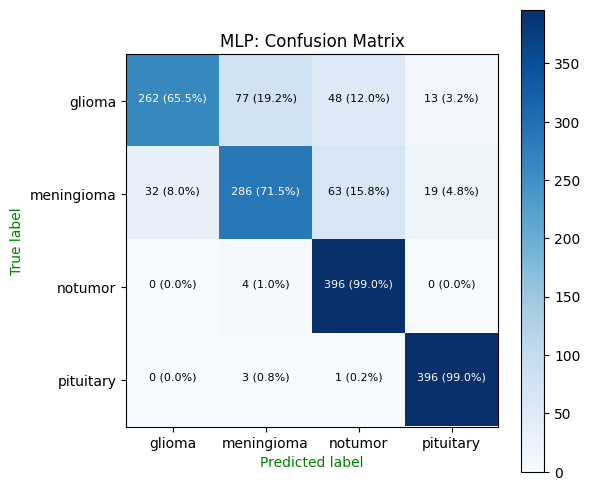

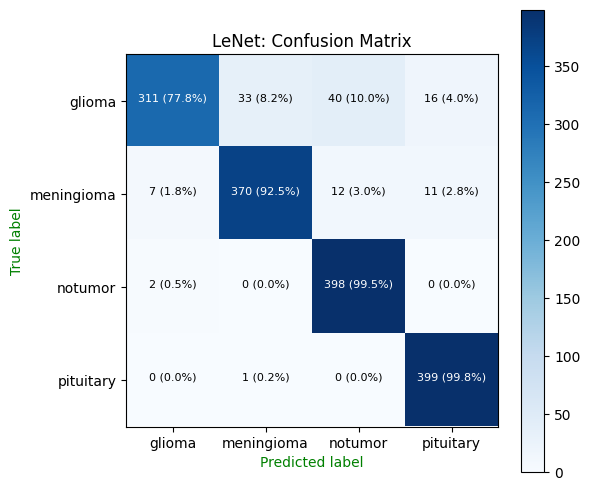

In [62]:
plot_complicated_confusion_matrix(mlp_test_labels, mlp_preds, class_names,
                                  fontsize=8, figsize=(6, 6), title="MLP: Confusion Matrix")
plot_complicated_confusion_matrix(lenet_test_labels, lenet_preds, class_names,
                                  fontsize=8, figsize=(6, 6), title="LeNet: Confusion Matrix")

### Classification Report

In the following code cell, we will **print the classification report** for our best model using the **test dataset**. This report includes **precision, recall, F1-score, and support** for each class, giving a comprehensive overview of the model's performance.


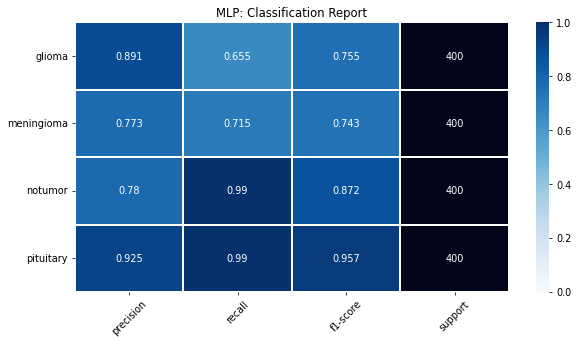

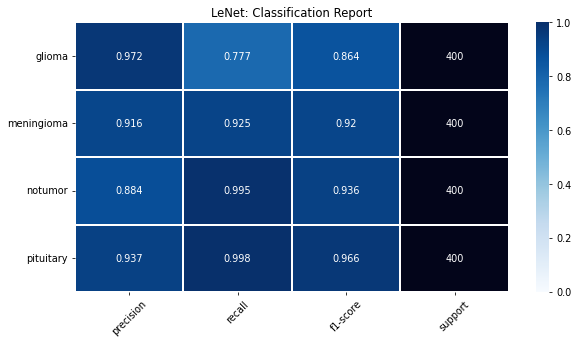

In [63]:
fig, ax = visualization.plot_classification_report(mlp_test_labels, mlp_preds,
                    title='MLP: Classification Report',
                    figsize=(10, 5), dpi=70,
                    target_names = class_names
)

fig, ax = visualization.plot_classification_report(lenet_test_labels, lenet_preds,
                    title='LeNet: Classification Report',
                    figsize=(10, 5), dpi=70,
                    target_names = class_names
)

### Misclassified Brain Tumors

In this section, we will **plot the images of tumors**, if any exist. This helps us **visually analyze the model's errors** and understand which types of brain tumour images are more challenging for the model to classify correctly.


In [64]:
mlp_corrects = torch.eq(torch.from_numpy(mlp_test_labels), torch.from_numpy(mlp_preds))
lenet_corrects = torch.eq(torch.from_numpy(lenet_test_labels), torch.from_numpy(lenet_preds))

In [65]:
def get_incorrect_examples(images, labels, probabilities, corrects):
  incorrect_examples = []
  for image, label, prob, correct in zip(images, labels, probabilities, corrects):
    if not correct:
      incorrect_examples.append((image, label, prob))
  return incorrect_examples

mlp_incorrect_examples = get_incorrect_examples(mlp_test_images, mlp_test_labels, mlp_probs, mlp_corrects)
lenet_incorrect_examples = get_incorrect_examples(lenet_test_images, lenet_test_labels, lenet_probs, lenet_corrects)

In [66]:
def plot_most_incorrect(incorrect, classes, n_images, normalize = True):
  rows = int(np.sqrt(n_images))
  cols = int(np.sqrt(n_images))
  fig = plt.figure(figsize = (6, 4))
  for i in range(rows*cols):
    ax = fig.add_subplot(rows, cols, i+1)
    image, true_label, probs = incorrect[i]
    image = image.permute(1, 2, 0)
    true_class = classes[true_label]
    incorrect_class = classes[0 if true_label == 1 else 1]
    if normalize:
      image = normalize_image(image)
    ax.imshow(image.cpu().numpy())
    ax.set_title(f'real: {true_class}\n' \
                  f'predicted: {incorrect_class}', fontsize=8)
    ax.axis('off')
  fig.subplots_adjust(hspace=0.4)

In the following code cell we are going to plot the most mispredicted `Brain Tumors` images by the model.

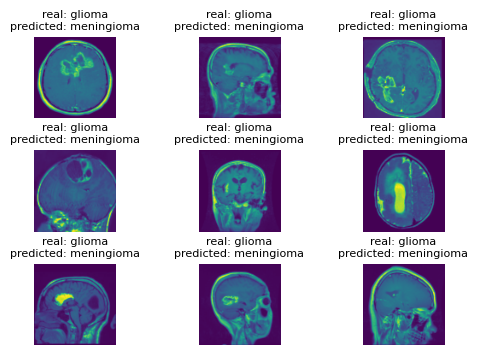

In [67]:
N_IMAGES = 12
try:
    plot_most_incorrect(mlp_incorrect_examples, class_names, N_IMAGES)
except:
    print("No incorrectly Predicted Images")

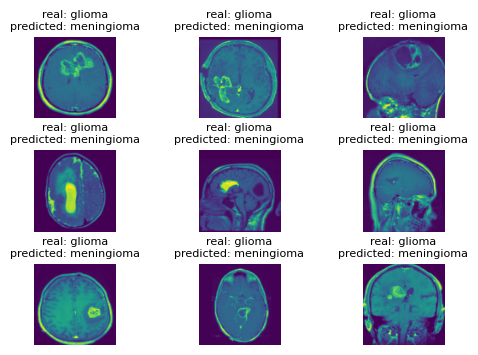

In [68]:
N_IMAGES = 12
try:
    plot_most_incorrect(lenet_incorrect_examples, class_names, N_IMAGES)
except:
    print("No incorrectly Predicted Images")